In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

: 

In [5]:
df = pd.read_csv("./content/study_performance.csv")

In [6]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [9]:
# this function is use to find my unique values
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [10]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [11]:
ak = list(df.columns)

In [12]:
np.dtype(df[ak[0]])

dtype('O')

In [13]:
c = []
n = []
for i in ak:
  if np.dtype(df[i]) == 'O':
    c.append(i)
  else:
    n.append(i)

In [14]:
c

['gender',
 'race_ethnicity',
 'parental_level_of_education',
 'lunch',
 'test_preparation_course']

In [15]:
n

['math_score', 'reading_score', 'writing_score']

In [16]:
df["gender"].value_counts()

female    518
male      482
Name: gender, dtype: int64

In [17]:
df["total_score"] = (df['math_score'] + df['reading_score'] + df['writing_score'])
df["AVG"] = df["total_score"]/3

In [18]:
df

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,AVG
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333
...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,282,94.000000
996,male,group C,high school,free/reduced,none,62,55,55,172,57.333333
997,female,group C,high school,free/reduced,completed,59,71,65,195,65.000000
998,female,group D,some college,standard,completed,68,78,77,223,74.333333


<Axes: xlabel='AVG', ylabel='Count'>

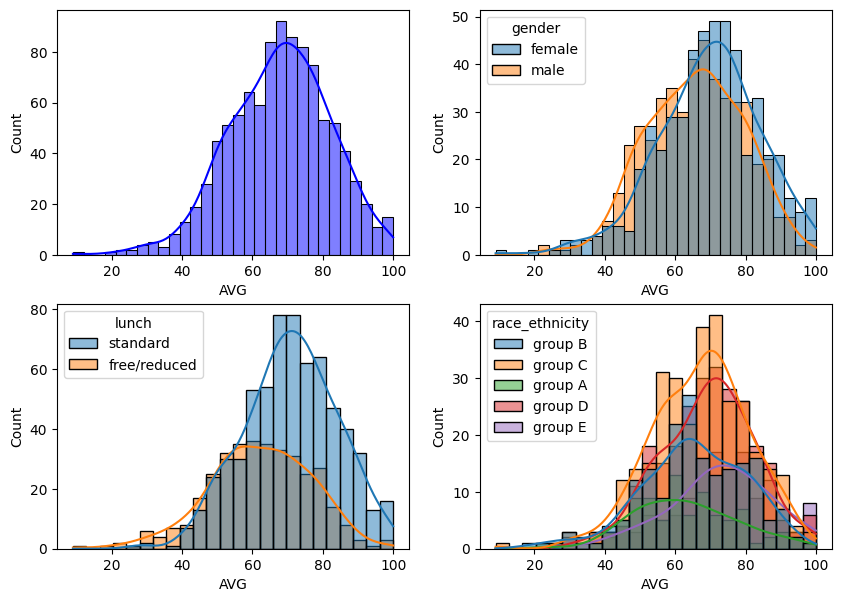

In [32]:
fig,axis = plt.subplots(2,2,figsize=(10,7))
plt.subplot(221)
sns.histplot(data=df,x='AVG',bins=30,kde=True,color='b')
plt.subplot(222)
sns.histplot(data=df,x='AVG',bins=30,kde=True,hue='gender')
plt.subplot(223)
sns.histplot(data=df,x="AVG",kde=True,hue="lunch")
plt.subplot(224)
sns.histplot(data=df,x="AVG",kde=True,hue="race_ethnicity")

TypeError: ignored

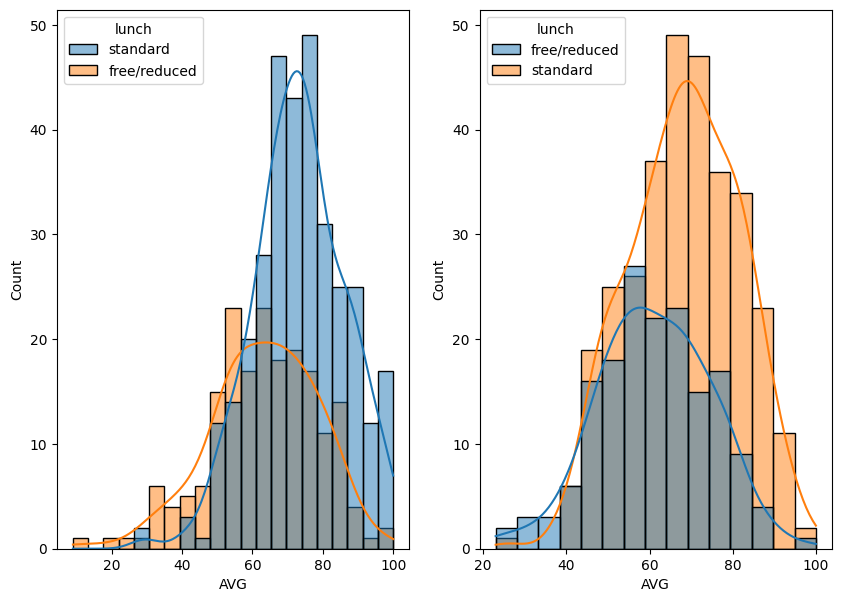

In [34]:
fig,axis=plt.subplots(1,2,figsize=(10,7))
plt.subplot(121)
sns.histplot(data=df[df['gender']=="female"],x="AVG",kde=True,hue="lunch")
plt.subplot(122)
sns.histplot(sns.histplot(data=df[df['gender']=="male"],x="AVG",kde=True,hue="lunch"))

<ipython-input-35-8df7bcac526d>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(),annot=True)


<Axes: >

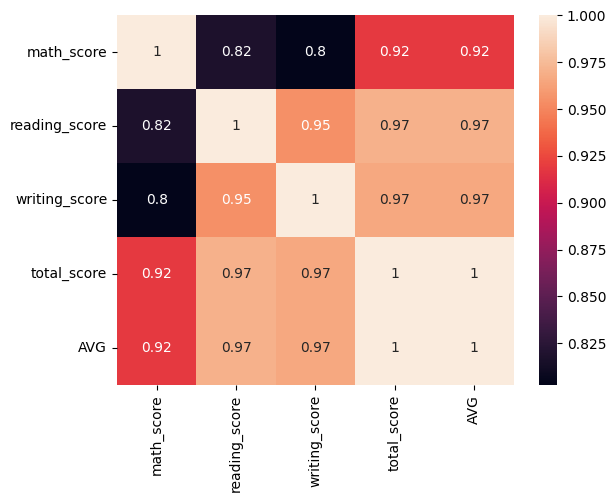

In [35]:
sns.heatmap(df.corr(),annot=True) # for my numerical data i will use my heatmap